## Goal and how to run

Download the complete `.ipynb`. In VibeIt Studio's file browser use **+ → Import from Files**, then open it. Run code cells from top to bottom. Saved charts show actual executed results; rerunning recomputes them from embedded data.

This lesson assumes basic Python knowledge. Read each method and caption before changing parameters. AI exercises are optional; no AI account is needed for the core workflow. Data lives in notebook metadata, so there is no companion data download. Keep the notebook saved in the active working folder.

Your goal is to understand the research question, execute transparent calculations, check the results, and state the limits of the conclusion.

## Setup and parameters

In [1]:
from pathlib import Path
import base64, gzip, hashlib, json, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML
from scipy.stats import spearmanr
from IPython.display import display as _display
def display(value):
    if isinstance(value,pd.DataFrame):
        table=value.to_html(max_rows=12,escape=True)
        style="<style>.vibeit-readable-table{max-width:100%;overflow-x:auto}.vibeit-readable-table table{width:max-content;max-width:none;border-collapse:collapse}.vibeit-readable-table td,.vibeit-readable-table th{white-space:nowrap!important;word-break:normal!important;overflow-wrap:normal!important}</style>"
        return _display(HTML(style+'<div class="vibeit-readable-table">'+table+'</div>'))
    return _display(value)
RECIPE_ID='hu06-social-indicators'
OUTPUT_DIR=Path.cwd()/"results"/RECIPE_ID
plt.rcParams.update({"figure.dpi":120,"font.size":10,"axes.spines.top":False,"axes.spines.right":False,
                      "axes.prop_cycle":plt.cycler(color=["#18785f","#416aa6","#bc6541","#9974a5"])})
print("Python:",platform.python_version(),"; NumPy:",np.__version__,"; Pandas:",pd.__version__)
print("Working folder:",Path.cwd())
print("Core data mode: embedded snapshot; no network requests")


Python: 3.13.13 ; NumPy: 2.5.3 ; Pandas: 3.0.6
Working folder: /Users/zhiluo/Developer/vibeit-cookbook/cookbook/downloads
Core data mode: embedded snapshot; no network requests


### Load the embedded snapshot

The loader locates this notebook in the working folder by recipe ID and SHA-256, then decompresses and verifies the data. Renaming the file does not change its identity. If loading fails, check the working folder and saved file. Metadata travels with `.ipynb` save/export; copying code to a standalone `.py` does not copy the dataset.

In [2]:
def load_snapshot(recipe_id, expected_sha256, snapshot_key):
    """Read embedded data from this notebook, including a renamed copy."""
    for path in sorted(Path.cwd().glob("*.ipynb")):
        try:
            notebook = json.loads(path.read_text(encoding="utf-8"))
            metadata = notebook.get("metadata", {}).get("vibeit_cookbook", {})
            blob = metadata.get("snapshots", {}).get(snapshot_key)
            if metadata.get("recipe_id") != recipe_id or not blob:
                continue
            if blob.get("sha256") != expected_sha256:
                continue
            raw = gzip.decompress(base64.b64decode(blob["gzip_base64"], validate=True))
            if hashlib.sha256(raw).hexdigest() != expected_sha256:
                raise ValueError("Embedded snapshot checksum mismatch: " + snapshot_key)
            return json.loads(raw)
        except (OSError, json.JSONDecodeError):
            continue
    raise FileNotFoundError(
        "Save/open the complete .ipynb in the active working folder. "
        "The embedded snapshot could not be located for " + recipe_id)

SNAPSHOT_HASHES={'worldbank': 'd45779250297fb9371748b85b81321b2ae88f93ecf70cfb88256647a68e54376'}
def snapshot(key):
    return load_snapshot(RECIPE_ID,SNAPSHOT_HASHES[key],key)
print("Embedded snapshots:",list(SNAPSHOT_HASHES))


Embedded snapshots: ['worldbank']


### Read the method functions

The full implementations appear below. They use the listed bundled packages and standard library; no cookbook helper module is imported at runtime. Inspect input requirements and return values. If you change an algorithm, its checks must still pass.

In [3]:
def worldbank_panel(payload):
    """Preserve missing observations; official economy metadata excludes aggregates."""
    economies=pd.DataFrame(payload['economies']).set_index('iso3')
    observations=pd.DataFrame(payload['observations'])
    observations=observations[observations.iso3.isin(economies.index)].copy()
    if observations.duplicated(['iso3','year','indicator']).any():raise ValueError('Duplicate economy/year/indicator observations')
    observations['value']=pd.to_numeric(observations.value,errors='raise')
    wide=observations.pivot(index=['iso3','year'],columns='indicator',values='value').sort_index()
    return wide,economies,observations

print("Method ready: worldbank_panel")


Method ready: worldbank_panel


### Data and model boundary

Use a declared 2023 economy-level cross-section. Life expectancy at birth is a period indicator based on mortality conditions, not a personal life prediction. Current frozen income-group metadata is not reconstructed historical classification. Complete-case selection and macro-level association cannot establish individual or causal effects.

## Steps

### 1. Join a common dated cross-section

Use 2023 economy-level GDP per capita in constant 2015 USD, population and life expectancy. Official metadata excludes aggregates. Keep missingness counts and current source income-group labels explicit.

In [4]:
wb=snapshot("worldbank");panel,economies,observations=worldbank_panel(wb)
year=2023;columns=["NY.GDP.PCAP.KD","SP.POP.TOTL","SP.DYN.LE00.IN"]
cross=panel.xs(year,level="year")[columns].rename(columns={columns[0]:"GDP_pc_constant_2015_USD",columns[1]:"population",columns[2]:"life_expectancy_years"})
coverage=cross.notna().sum();usable=cross.dropna().join(economies[["name","income_group"]])
assert usable.GDP_pc_constant_2015_USD.gt(0).all() and usable.population.gt(0).all()
assert usable.life_expectancy_years.between(0,110).all()
print("Year:",year,"; complete economies:",len(usable),"of",len(cross));display(coverage.to_frame("observed_economies"))
display(usable.head(8))


Year: 2023 ; complete economies: 203 of 217


,observed_economies
indicator,
GDP_pc_constant_2015_USD,203
population,217
life_expectancy_years,217


,GDP_pc_constant_2015_USD,population,life_expectancy_years,name,income_group
iso3,,,,,
ABW,31963.076451,107359.0,76.353000,Aruba,High income
AFG,378.066303,41454761.0,66.035000,Afghanistan,Low income
AGO,2748.951970,36749906.0,64.617000,Angola,Lower middle income
ALB,6204.435256,2411658.0,79.602000,Albania,Upper middle income
AND,40227.233530,80856.0,84.041000,Andorra,High income
ARE,41926.577350,10483751.0,82.909000,United Arab Emirates,High income
ARG,12993.092887,45538401.0,77.395000,Argentina,Upper middle income
ARM,5197.235090,2964300.0,77.465854,Armenia,Upper middle income


### 2. Read an economy-level association

The x axis is log-scaled constant-price GDP per capita and y is period life expectancy at birth. Each marker is one economy, not an individual. This does not estimate what raising an individual’s income would do to their lifespan.

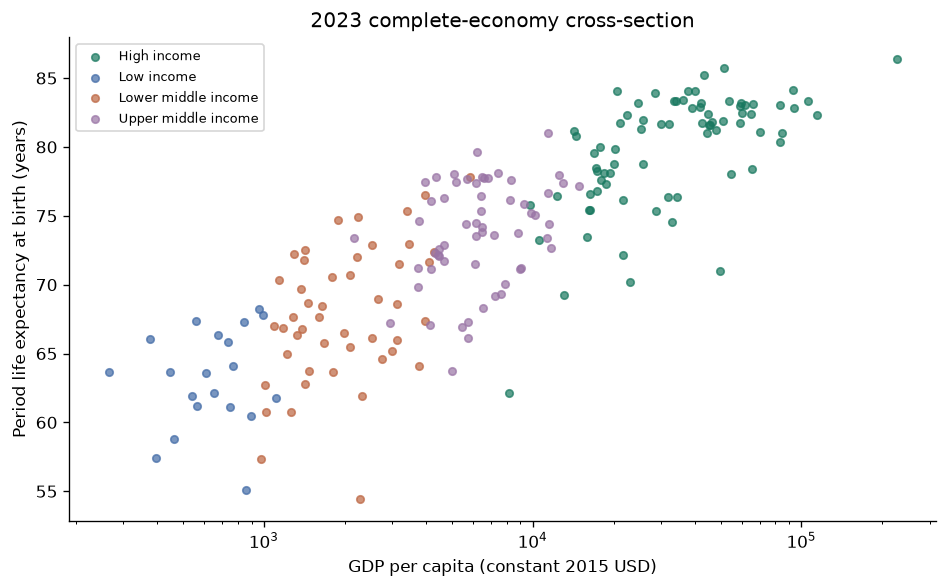

In [5]:
fig,ax=plt.subplots(figsize=(8,5))
for group,part in usable.groupby("income_group"):ax.scatter(part.GDP_pc_constant_2015_USD,part.life_expectancy_years,label=group,s=20,alpha=.7)
ax.set(xscale="log",xlabel="GDP per capita (constant 2015 USD)",ylabel="Period life expectancy at birth (years)",title="2023 complete-economy cross-section");ax.legend(fontsize=8);plt.tight_layout();plt.show()


### 3. Inspect group distributions with a dated classification caveat

Boxplots use current frozen source income-group metadata applied to 2023 observations. They do not reconstruct past group classification. Country values are not population-weighted household observations.

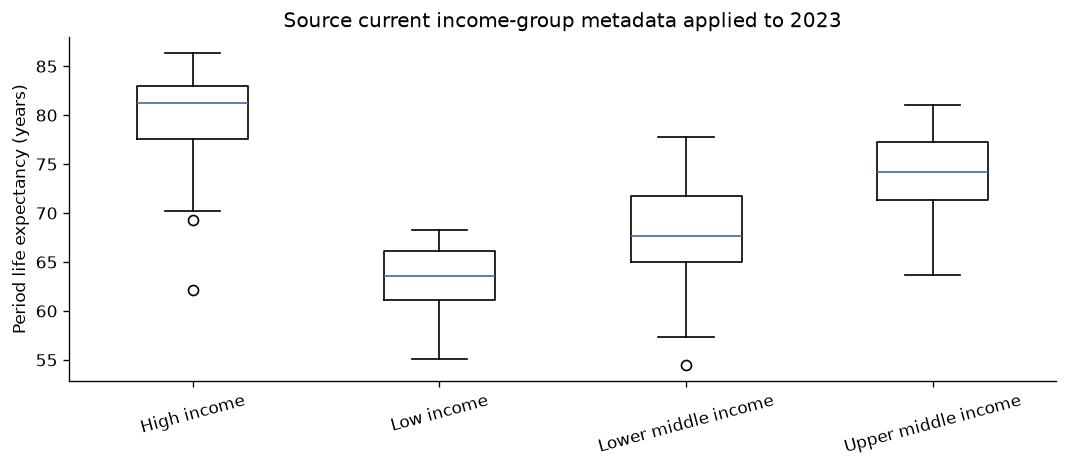

In [6]:
groups=sorted(usable.income_group.unique())
fig,ax=plt.subplots(figsize=(9,4));ax.boxplot([usable.loc[usable.income_group.eq(g),"life_expectancy_years"] for g in groups],tick_labels=groups)
ax.set(ylabel="Period life expectancy (years)",title="Source current income-group metadata applied to 2023");plt.xticks(rotation=15);plt.tight_layout();plt.show()


### 4. Compare association measures and transformations

Pearson on log GDP and Spearman on raw GDP answer related but different descriptive questions. Bar coefficients are not causal effects or probability of a personal outcome. Report sample size and complete-case selection.

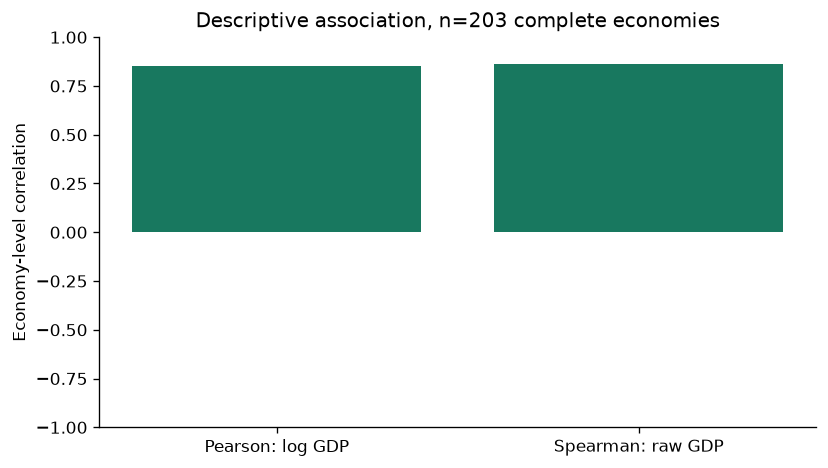

In [7]:
pearson=float(np.corrcoef(np.log(usable.GDP_pc_constant_2015_USD),usable.life_expectancy_years)[0,1])
spearman=float(spearmanr(usable.GDP_pc_constant_2015_USD,usable.life_expectancy_years).statistic)
fig,ax=plt.subplots(figsize=(7,4));ax.bar(["Pearson: log GDP","Spearman: raw GDP"],[pearson,spearman])
ax.set(ylim=(-1,1),ylabel="Economy-level correlation",title=f"Descriptive association, n={len(usable)} complete economies");plt.tight_layout();plt.show()


### 5. Audit selection and export definitions

Confirm IDs belong to official nonaggregate economy metadata and correlation lies in [−1,1]. Save the complete-case rows and missingness, not just the scatter. A cross-section cannot resolve individual or causal questions.

In [8]:
assert set(usable.index)<=set(economies.index) and -1<=pearson<=1 and -1<=spearman<=1
assert len(usable)==int(cross.notna().all(axis=1).sum())
OUTPUT_DIR.mkdir(parents=True,exist_ok=True);usable.to_csv(OUTPUT_DIR/"2023-complete-economies.csv")
cross.to_csv(OUTPUT_DIR/"2023-source-with-missingness.csv")
(OUTPUT_DIR/"scope.json").write_text(json.dumps({"year":year,"units":{"GDP_pc":"constant 2015 USD","population":"persons","life_expectancy":"period years at birth"},"n_complete_economies":len(usable),"classification":"current frozen income-group metadata, not historical reconstruction","association":{"pearson_log_GDP":pearson,"spearman_GDP":spearman},"inference":"economy-level descriptive; no individual or causal claim"},indent=2))
print("Economy IDs, dated selection and units checked; exports:",OUTPUT_DIR)


Economy IDs, dated selection and units checked; exports: /Users/zhiluo/Developer/vibeit-cookbook/cookbook/downloads/results/hu06-social-indicators


## Exercises and reference explanation

1. Why is this an ecological rather than individual association?
2. What does current metadata applied to 2023 mean?

**Reference explanation.** The unit is an economy, not a person. Frozen current income-group labels do not reconstruct historical classification; missing selection and confounding remain.

Keep a copy before changing parameters. Compare old and new figures and record which inputs, calculations and conclusions changed.

## Optional AI coding exercises

Open the current notebook in VibeIt's Coding Agent and ask it to read the relevant cells. The core lesson does not depend on AI access; see the Help Center for provider and account setup.

**Prompt 1**

> Using NumPy/SciPy/Pandas/Matplotlib, repeat a declared common-year comparison and report changing sample coverage.

**Prompt 2**

> With the same packages, export complete-case and missing rows separately and label all units/current classifications.

**Human acceptance.** Aggregates stay excluded, dates match, IDs/coverage reconcile and no individual or causal effect is inferred.

Review the edited source, then manually run affected cells and subsequent checks. Ask the assistant to explain the purpose, packages and data provenance of its changes, and reconcile that explanation with actual output.

## Optional online extension

The network action below is disabled by default. It reports a database version/source without replacing the core data. To refresh data, save a separate experimental version and record the new URL, database release, retrieval date and SHA-256. New results require rerunning and validation.

In [9]:
RUN_ONLINE_UPDATE=False
if RUN_ONLINE_UPDATE:
    import requests
    try:
        response=requests.get('https://api.worldbank.org/v2/indicator/SP.DYN.LE00.IN?format=json',timeout=20)
        response.raise_for_status()
        print("Source:",response.url)
        print(response.text[:700])
    except requests.RequestException as error:
        print("Online extension unavailable:",type(error).__name__,str(error)[:160])
else:
    print("Online extension skipped; embedded core data unchanged")


Online extension skipped; embedded core data unchanged


## Sources, snapshots and next steps

- [World Bank economy metadata](https://api.worldbank.org/v2/country?format=json&per_page=400) — World Bank CC BY 4.0 with additional terms; retain original indicator attribution; retrieved 2026-10-09. SHA-256 `c9acf3932785191a649cbc04c3056af4cf64a236e5c3b49d49be25ddb0440bce`.
  Preserve economy IDs, region and income-group metadata; exclude aggregates in student analyses.

- [World Bank NY.GDP.PCAP.KD](https://api.worldbank.org/v2/country/all/indicator/NY.GDP.PCAP.KD?date=2010:2024&format=json&per_page=20000&footnote=y) — World Bank CC BY 4.0 with additional terms; original sources retained in indicator metadata; retrieved 2026-10-09. SHA-256 `59a9efaf20ab359c7832f24da45dda2282511c0eaf927d044583f47d08e02cda`.
  Retain official observations including null values and footnotes, 2010–2024; no interpolation; no aggregate-country mixing.

- [World Bank indicator metadata NY.GDP.PCAP.KD](https://api.worldbank.org/v2/indicator/NY.GDP.PCAP.KD?format=json) — World Bank CC BY 4.0 with additional terms; retrieved 2026-10-09. SHA-256 `46689488cd435920647264ede1bfb2d4b51b09800fb36f3d3b1422a0b11ea49d`.
  Preserve indicator definition, source organization and source note.

- [World Bank NY.GDP.MKTP.KD](https://api.worldbank.org/v2/country/all/indicator/NY.GDP.MKTP.KD?date=2010:2024&format=json&per_page=20000&footnote=y) — World Bank CC BY 4.0 with additional terms; original sources retained in indicator metadata; retrieved 2026-10-09. SHA-256 `466f4e3176b509613f3df99acffce89b5f1ea14472c376dd10d8b8f67f6172b0`.
  Retain official observations including null values and footnotes, 2010–2024; no interpolation; no aggregate-country mixing.

- [World Bank indicator metadata NY.GDP.MKTP.KD](https://api.worldbank.org/v2/indicator/NY.GDP.MKTP.KD?format=json) — World Bank CC BY 4.0 with additional terms; retrieved 2026-10-09. SHA-256 `bc4bc0ffec1755410f52b1091c6b1f46917c7417977102350d3d1102b4659216`.
  Preserve indicator definition, source organization and source note.

- [World Bank SP.POP.TOTL](https://api.worldbank.org/v2/country/all/indicator/SP.POP.TOTL?date=2010:2024&format=json&per_page=20000&footnote=y) — World Bank CC BY 4.0 with additional terms; original sources retained in indicator metadata; retrieved 2026-10-09. SHA-256 `7ecf8d749dbddd87a269f2019e6d42ed32875c57565cf5c5af097c6e6c9af528`.
  Retain official observations including null values and footnotes, 2010–2024; no interpolation; no aggregate-country mixing.

- [World Bank indicator metadata SP.POP.TOTL](https://api.worldbank.org/v2/indicator/SP.POP.TOTL?format=json) — World Bank CC BY 4.0 with additional terms; retrieved 2026-10-09. SHA-256 `2f8491efc00bf2c0995112ff8e87aba69e5e9d22d0880b22f7e3a4ec757ba05c`.
  Preserve indicator definition, source organization and source note.

- [World Bank SP.DYN.LE00.IN](https://api.worldbank.org/v2/country/all/indicator/SP.DYN.LE00.IN?date=2010:2024&format=json&per_page=20000&footnote=y) — World Bank CC BY 4.0 with additional terms; original sources retained in indicator metadata; retrieved 2026-10-09. SHA-256 `d8b5c6bd7fecaf8cee0e422444719ba1f42ec70996308bc74afd14ee48799055`.
  Retain official observations including null values and footnotes, 2010–2024; no interpolation; no aggregate-country mixing.

- [World Bank indicator metadata SP.DYN.LE00.IN](https://api.worldbank.org/v2/indicator/SP.DYN.LE00.IN?format=json) — World Bank CC BY 4.0 with additional terms; retrieved 2026-10-09. SHA-256 `a39cb6fddfbbb953053690366243dffe77a266c4deae79c46ce5a06da9f5fc31`.
  Preserve indicator definition, source organization and source note.

- [World Bank FP.CPI.TOTL](https://api.worldbank.org/v2/country/all/indicator/FP.CPI.TOTL?date=2010:2024&format=json&per_page=20000&footnote=y) — World Bank CC BY 4.0 with additional terms; original sources retained in indicator metadata; retrieved 2026-10-09. SHA-256 `55c3b71ad4dd8c92c15fa7dc2b502a3d60f26cf47ae9a24e384bc2ff6108ff56`.
  Retain official observations including null values and footnotes, 2010–2024; no interpolation; no aggregate-country mixing.

- [World Bank indicator metadata FP.CPI.TOTL](https://api.worldbank.org/v2/indicator/FP.CPI.TOTL?format=json) — World Bank CC BY 4.0 with additional terms; retrieved 2026-10-09. SHA-256 `13b1e3c4b2b72f7fb3a630b4dde37f0e68e6d5e78dc06b2437dfea0c0b93af46`.
  Preserve indicator definition, source organization and source note.

- [World Bank FP.CPI.TOTL.ZG](https://api.worldbank.org/v2/country/all/indicator/FP.CPI.TOTL.ZG?date=2010:2024&format=json&per_page=20000&footnote=y) — World Bank CC BY 4.0 with additional terms; original sources retained in indicator metadata; retrieved 2026-10-09. SHA-256 `849b6a88a84a7efdeb92d89e8db1db36f86543e28ff8eb645e0feaa8c634def7`.
  Retain official observations including null values and footnotes, 2010–2024; no interpolation; no aggregate-country mixing.

- [World Bank indicator metadata FP.CPI.TOTL.ZG](https://api.worldbank.org/v2/indicator/FP.CPI.TOTL.ZG?format=json) — World Bank CC BY 4.0 with additional terms; retrieved 2026-10-09. SHA-256 `df9371a3b6c01e55a3f28991e62e1b1ebbe0cd2a7da94456be9938c7a2962233`.
  Preserve indicator definition, source organization and source note.

- [World Bank SI.POV.GINI](https://api.worldbank.org/v2/country/all/indicator/SI.POV.GINI?date=2010:2024&format=json&per_page=20000&footnote=y) — World Bank CC BY 4.0 with additional terms; original sources retained in indicator metadata; retrieved 2026-10-09. SHA-256 `4919413d3b9ef06b7445c3fd42d47b8a09e9836bbab7be84e4993099ffdc7ab2`.
  Retain official observations including null values and footnotes, 2010–2024; no interpolation; no aggregate-country mixing.

- [World Bank indicator metadata SI.POV.GINI](https://api.worldbank.org/v2/indicator/SI.POV.GINI?format=json) — World Bank CC BY 4.0 with additional terms; retrieved 2026-10-09. SHA-256 `e377bf82b38024748153880ff90c0106a0ef0fd8cb04761146cc60a2609cab3d`.
  Preserve indicator definition, source organization and source note.


**Next steps.** Transfer these methods to your own public or authorized data while retaining input checks, recorded parameters and result validation. Document the new experimental design and method limits; this example does not validate a new experiment. Full data licenses and generation instructions accompany the cookbook.